In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/FAOSTAT_data_forest_emissionssami.csv")

pd.set_option("display.max_columns", None)

display(df)













,Domain,Area,Element,Item,Year,Source,Unit,Value
0,Emissions from Forests,Syrian Arab Republic,Area,Forestland,1990,FAO TIER 1,1000 ha,450.9900
1,Emissions from Forests,Syrian Arab Republic,Net emissions,Forestland,1990,FAO TIER 1,kt,-1525.3333
2,Emissions from Forests,Syrian Arab Republic,Area,Forestland,1991,FAO TIER 1,1000 ha,451.9680
3,Emissions from Forests,Syrian Arab Republic,Net emissions,Forestland,1991,FAO TIER 1,kt,-1525.3333
4,Emissions from Forests,Syrian Arab Republic,Area,Forestland,1992,FAO TIER 1,1000 ha,452.9460
...,...,...,...,...,...,...,...,...
211,Emissions from Forests,Syrian Arab Republic,Net emissions,Carbon stock,2023,FAO TIER 1,kt,-1884.6667
212,Emissions from Forests,Syrian Arab Republic,Area,Carbon stock,2024,FAO TIER 1,1000 ha,527.7780
213,Emissions from Forests,Syrian Arab Republic,Net emissions,Carbon stock,2024,FAO TIER 1,kt,-1884.6667
214,Emissions from Forests,Syrian Arab Republic,Area,Carbon stock,2025,FAO TIER 1,1000 ha,527.8100


In [ ]:
# Compare the average net emissions between the beginning and the end of the study period.
# We compare 1990–1994 with 2020–2024 to identify how the average changed over time.

early_period = forest_emissions[
    forest_emissions["Year"].between(1990, 1994)
]

late_period = forest_emissions[
    forest_emissions["Year"].between(2020, 2024)
]

early_average = early_period["Value"].mean()
late_average = late_period["Value"].mean()

difference = late_average - early_average

print("--- Period Comparison ---")
print("Average net emissions (2000–2004):", round(early_average, 2), "kt")
print("Average net emissions (2020–2024):", round(late_average, 2), "kt")
print("Different between periods:", round(difference, 2), "kt")



--- Period Comparison ---
Average net emissions (2000–2004): -1663.2 kt
Average net emissions (2020–2024): -1783.47 kt
Different between periods: -120.27 kt


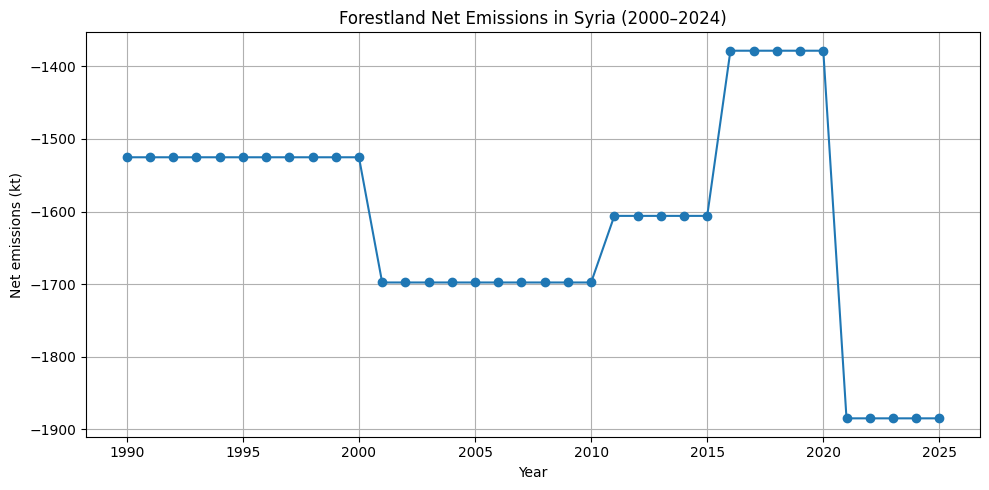

In [ ]:
# Create a line chart to visualize the change in Forestland net emissions over time.
# The graph makes it easier to identify changes and different periods in the dataset.

plt.figure(figsize=(10, 5))

plt.plot(
    forest_emissions["Year"],
    forest_emissions["Value"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Net emissions (kt)")
plt.title("Forestland Net Emissions in Syria (2000–2024)")

plt.grid(True)
plt.tight_layout()
plt.show()

### Find

The graph shows clear changes in Forestland net emissions over the study period. The values remained relatively stable during some periods, while noticeable changes occurred around 2000, 2011, 2016, and 2021.

In [ ]:
# Calculate the overall linear trend over the study period.
# The slope shows the average change in net emissions for each year.
# A positive slope means the recorded values tend to increase over time.
# A negative slope means the recorded values tend to decrease over time.

import numpy as np

slope, intercept = np.polyfit(
    forest_emissions["Year"],
    forest_emissions["Value"],
    1
)

print("-- Trend Analysis --")
print("Annual trend:", round(slope, 2), "kt/year")

-- Trend Analysis --
Annual trend: -4.87 kt/year


In [ ]:
# Compare the first and last years of the study period.
# This shows how the recorded net emissions changed between 1990 and 2024.

value_1990 = forest_emissions.loc[
    forest_emissions["Year"] == 1990, "Value"
].iloc[0]

value_2024 = forest_emissions.loc[
    forest_emissions["Year"] == 2024, "Value"
].iloc[0]

absolute_change = value_2024 - value_1990

magnitude_change = (
    (abs(value_2024) - abs(value_2000))
    / abs(value_2000)
) * 100

print("--- Change Analysis ---")
print("Net emissions in 2000:", value_1990, "kt")
print("Net emission in 2024:", value_2024, "kt")
print("Absolute change:", round(absolute_change, 2), "kt")
print(
    "Change in magnitude:",
    round(magnitude_change, 2),
    "%"
)

--- Change Analysis ---
Net emissions in 2000: -1525.3333 kt
Net emission in 2024: -1884.6667 kt
Absolute change: -359.33 kt
Change in magnitude: 23.56 %


In [ ]:
# Calculate basic statistics for Forestland net emissions.
# These values help us summarize the overall level and range of the data.

average = forest_emissions["Value"].mean()

maximum = forest_emissions["Value"].max()
minimum = forest_emissions["Value"].min()

max_year = forest_emissions.loc[
    forest_emissions["Value"].idxmax(), "Year"
]

min_year = forest_emissions.loc[
    forest_emissions["Value"].idxmin(), "Year"
]

print("--- Basic Statistics ---")
print("average net emissions:", round(average, 2), "kt")
print("Max value:", maximum, "kt in", max_year)
print("Mini value:", minimum, "kt in", min_year)


--- Basic Statistics ---
average net emissions: -1613.94 kt
Max value: -1378.6667 kt in 2016
Mini value: -1884.6667 kt in 2021


In [ ]:
forest_emissions = df[
    (df["Element"] == "Net emissions") &
    (df["Item"] == "Forestland")
]

print("Forestland Net Emissions:")
display(forest_emissions[["Year", "Value", "Unit"]])


Forestland Net Emissions:


,Year,Value,Unit
1,1990,-1525.3333,kt
3,1991,-1525.3333,kt
5,1992,-1525.3333,kt
7,1993,-1525.3333,kt
9,1994,-1525.3333,kt
11,1995,-1525.3333,kt
13,1996,-1525.3333,kt
15,1997,-1525.3333,kt
17,1998,-1525.3333,kt
19,1999,-1525.3333,kt


In [ ]:
df = df[(df["Year"] >= 1990) & (df["Year"] <= 2025)]

print("Study period:")
print(df["Year"].min(), "to", df["Year"].max())

print("Number of years:", df["Year"].nunique())


Study period:
1990 to 2025
Number of years: 36


In [ ]:
# Check the structure of the dataset:
# This shows the column names, data types, number of rows,
# and whether there are missing values.
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domain   216 non-null    object 
 1   Area     216 non-null    object 
 2   Element  216 non-null    object 
 3   Item     216 non-null    object 
 4   Year     216 non-null    int64  
 5   Source   216 non-null    object 
 6   Unit     216 non-null    object 
 7   Value    216 non-null    float64
dtypes: float64(1), int64(1), object(6)
memory usage: 13.6+ KB
